<a href="https://colab.research.google.com/github/deeplearningmn/AIEng/blob/main/4.ml/homework/daalgavar_bitcoinii_hansh_(ganchimeg%2Czorigt).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Биткойны сүүлийн 365 өдрийн ханш: 104935.0695889889 USD
Ирээдүйн ханшийн таамаг: 117949.94215798643 USD


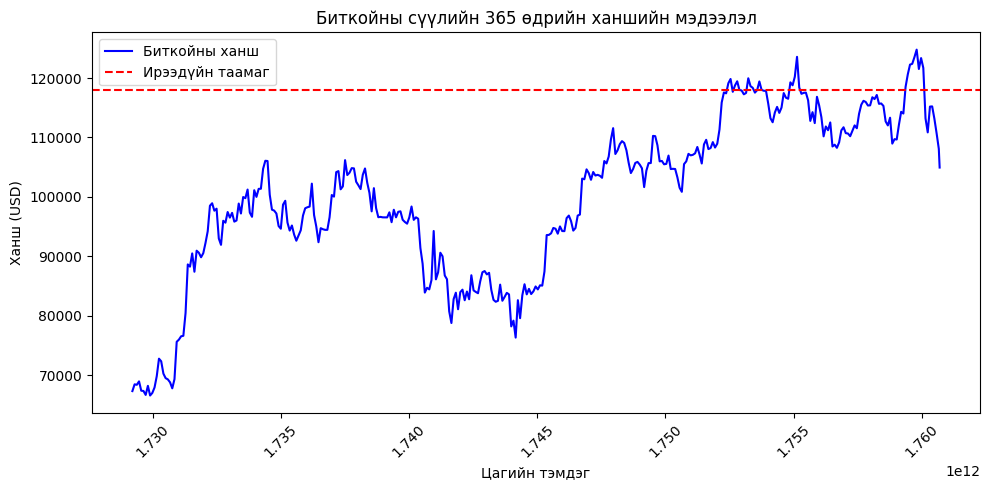

Биткойны ханш өсч байна.


In [1]:
import requests
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def fetch_bitcoin_price_history():
    # CoinGecko API-гаас Биткойны сүүлийн 365 өдрийн ханшийн мэдээллийг авах
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=365"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        prices = data['prices']  # Ханшийн мэдээлэл
        timestamps = [price[0] for price in prices]  # Цагийн тэмдэг
        values = [price[1] for price in prices]  # Ханшийн утгууд

        # Ханшийн өсөлт, бууралтыг тооцоолох
        X = np.array(range(len(values))).reshape(-1, 1)  # Цагийн тэмдэг
        y = np.array(values)  # Ханшийн утгууд

        model = LinearRegression()
        model.fit(X, y)

        # Ханшийн хандлагыг таамаглах
        future_price = model.predict(np.array([[len(values)]]))  # Ирээдүйн ханш
        print(f"Биткойны сүүлийн 365 өдрийн ханш: {values[-1]} USD")
        print(f"Ирээдүйн ханшийн таамаг: {future_price[0]} USD")

        # График зурах
        plt.figure(figsize=(10, 5))
        plt.plot(timestamps, values, label='Биткойны ханш', color='blue')
        plt.axhline(y=future_price[0], color='red', linestyle='--', label='Ирээдүйн таамаг')
        plt.title('Биткойны сүүлийн 365 өдрийн ханшийн мэдээлэл')
        plt.xlabel('Цагийн тэмдэг')
        plt.ylabel('Ханш (USD)')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Ханшийн өсөлт, бууралт
        if future_price[0] > values[-1]:
            print("Биткойны ханш өсч байна.")
        else:
            print("Биткойны ханш буурч байна.")
    else:
        print("Мэдээллийг авахад алдаа гарлаа.")

# Функцийг дуудаж ханшийн мэдээллийг хэвлэх
fetch_bitcoin_price_history()
